In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style('whitegrid')

print(" Libraries loaded successfully!")

 Libraries loaded successfully!


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/churn-bigml-80 coddeva level 1 task 1 2 3/churn_cleaned coddeva level 1 task1.csv')

print(" Dataset loaded!")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
df.head()

 Dataset loaded!
Rows: 2666 | Columns: 20


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


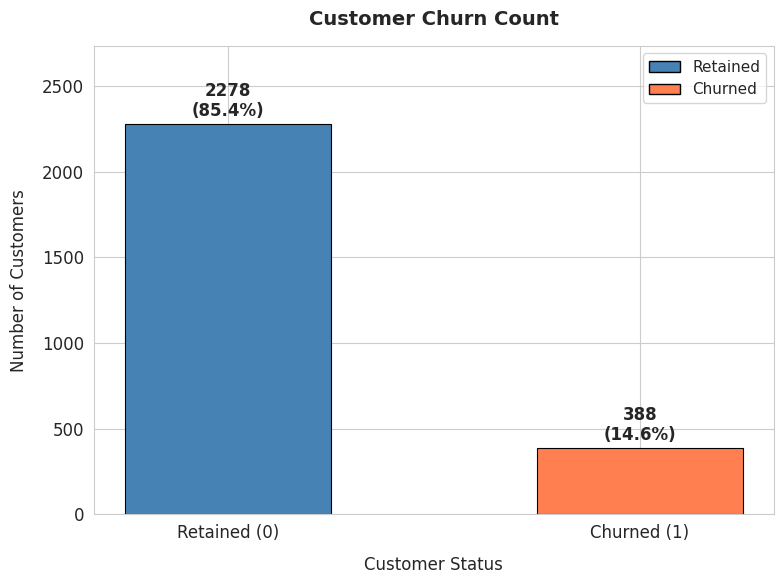

 Saved: bar_plot_churn_count.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

churn_counts = df['Churn'].value_counts()
labels = ['Retained (0)', 'Churned (1)']
colors = ['steelblue', 'coral']

bars = ax.bar(labels,
              churn_counts.values,
              color=colors,
              edgecolor='black',
              linewidth=0.8,
              width=0.5)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            height + 20,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold')

ax.set_title('Customer Churn Count', pad=15)
ax.set_xlabel('Customer Status', labelpad=10)
ax.set_ylabel('Number of Customers', labelpad=10)
ax.set_ylim(0, max(churn_counts.values) * 1.2)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', edgecolor='black', label='Retained'),
                   Patch(facecolor='coral', edgecolor='black', label='Churned')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('bar_plot_churn_count.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: bar_plot_churn_count.png")

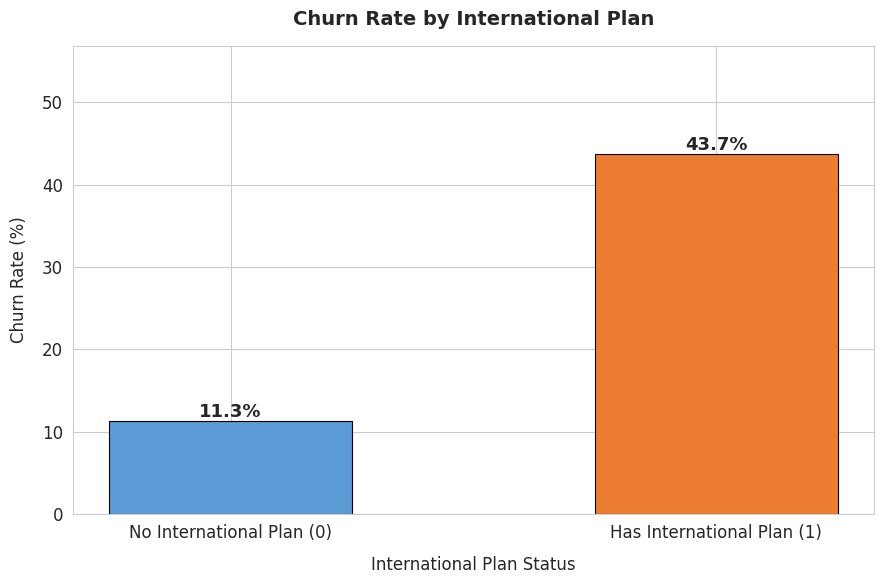

Saved: bar_plot_intl_plan_churn.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

intl_churn = df.groupby('International plan')['Churn'].mean() * 100
labels = ['No International Plan (0)', 'Has International Plan (1)']
colors = ['#5B9BD5', '#ED7D31']

bars = ax.bar(labels,
              intl_churn.values,
              color=colors,
              edgecolor='black',
              linewidth=0.8,
              width=0.5)

# Add percentage labels
for bar, val in zip(bars, intl_churn.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center',
            fontsize=13,
            fontweight='bold')

ax.set_title('Churn Rate by International Plan', pad=15)
ax.set_xlabel('International Plan Status', labelpad=10)
ax.set_ylabel('Churn Rate (%)', labelpad=10)
ax.set_ylim(0, max(intl_churn.values) * 1.3)

plt.tight_layout()
plt.savefig('bar_plot_intl_plan_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bar_plot_intl_plan_churn.png")

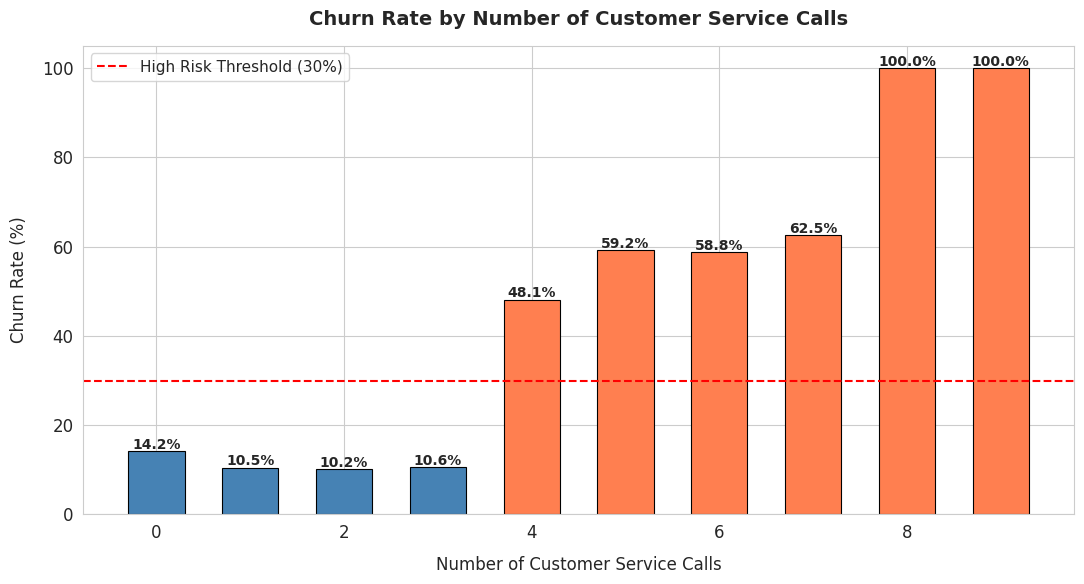

 Saved: bar_plot_service_calls_churn.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

cs_churn = df.groupby('Customer service calls')['Churn'].mean() * 100

bars = ax.bar(cs_churn.index,
              cs_churn.values,
              color='steelblue',
              edgecolor='black',
              linewidth=0.8,
              width=0.6)

# Color bars above 30% churn rate in red
for bar, val in zip(bars, cs_churn.values):
    if val > 30:
        bar.set_facecolor('coral')
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center',
            fontsize=10,
            fontweight='bold')

ax.axhline(y=30, color='red', linestyle='--',
           linewidth=1.5, label='High Risk Threshold (30%)')

ax.set_title('Churn Rate by Number of Customer Service Calls', pad=15)
ax.set_xlabel('Number of Customer Service Calls', labelpad=10)
ax.set_ylabel('Churn Rate (%)', labelpad=10)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('bar_plot_service_calls_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: bar_plot_service_calls_churn.png")

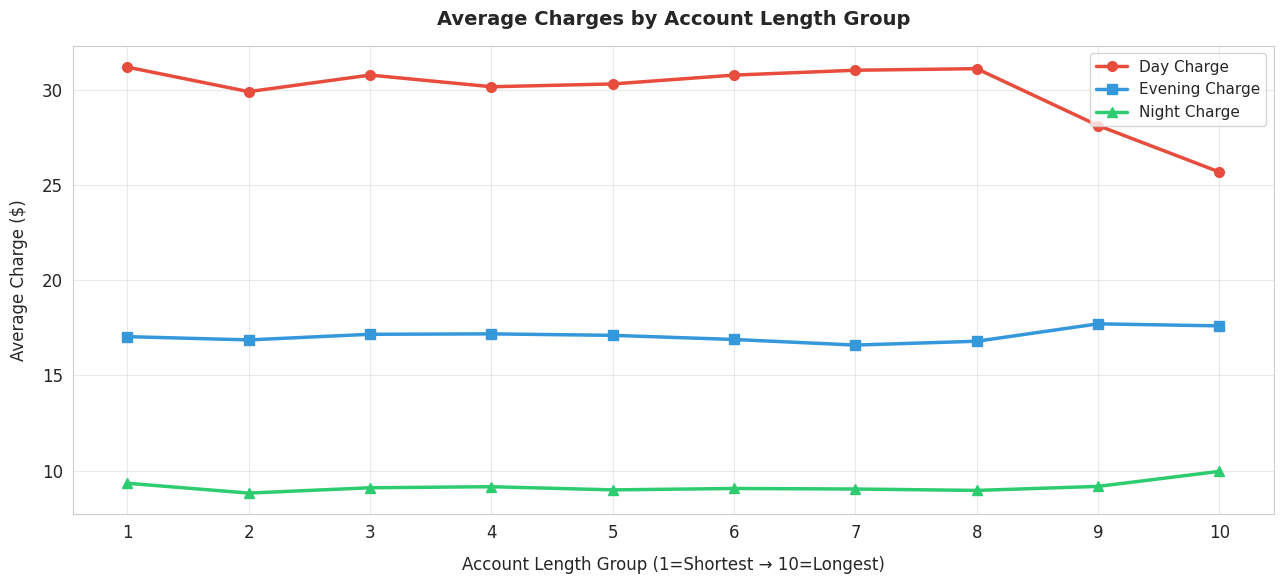

 Saved: line_chart_charges.png


In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

# Group by account length bins
df['Account_bin'] = pd.cut(df['Account length'], bins=10)
line_data = df.groupby('Account_bin', observed=True)[
    ['Total day charge', 'Total eve charge', 'Total night charge']
].mean()

x_labels = [str(i+1) for i in range(len(line_data))]

ax.plot(x_labels, line_data['Total day charge'],
        marker='o', linewidth=2.5, markersize=7,
        color='#E74C3C', label='Day Charge')

ax.plot(x_labels, line_data['Total eve charge'],
        marker='s', linewidth=2.5, markersize=7,
        color='#3498DB', label='Evening Charge')

ax.plot(x_labels, line_data['Total night charge'],
        marker='^', linewidth=2.5, markersize=7,
        color='#2ECC71', label='Night Charge')

ax.set_title('Average Charges by Account Length Group', pad=15)
ax.set_xlabel('Account Length Group (1=Shortest → 10=Longest)', labelpad=10)
ax.set_ylabel('Average Charge ($)', labelpad=10)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('line_chart_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: line_chart_charges.png")

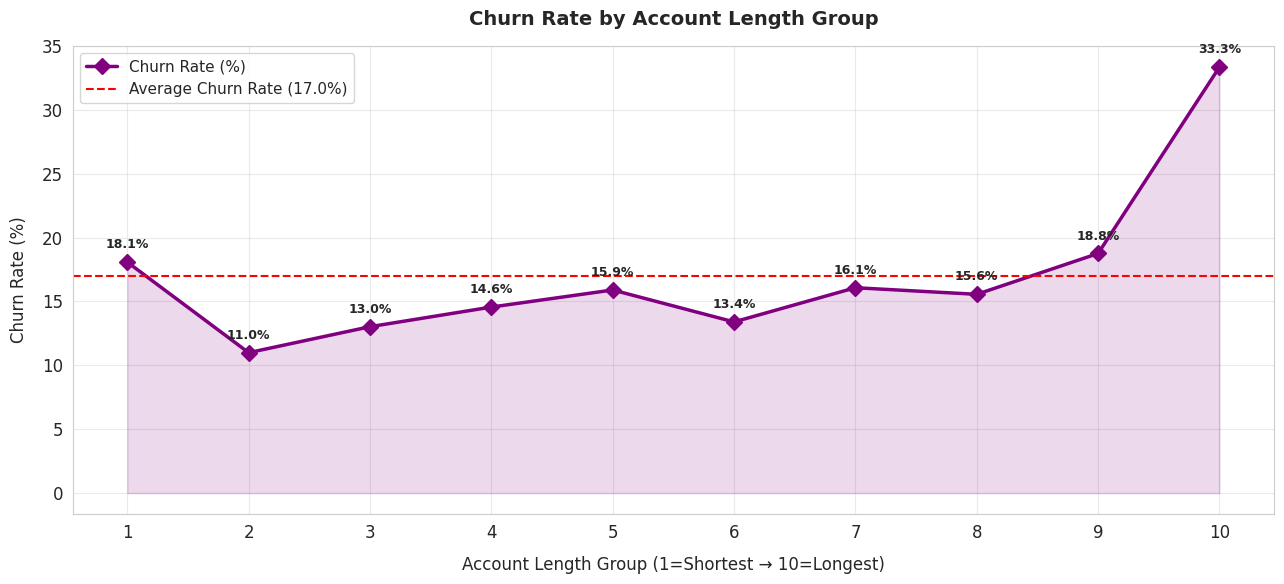

 Saved: line_chart_churn_by_length.png


In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))

churn_by_length = df.groupby('Account_bin', observed=True)['Churn'].mean() * 100

ax.plot(x_labels, churn_by_length.values,
        marker='D', linewidth=2.5, markersize=8,
        color='purple', label='Churn Rate (%)')

# Fill area under line
ax.fill_between(x_labels, churn_by_length.values,
                alpha=0.15, color='purple')

# Add value annotations
for i, val in enumerate(churn_by_length.values):
    ax.annotate(f'{val:.1f}%',
                xy=(x_labels[i], val),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center', fontsize=9,
                fontweight='bold')

ax.axhline(y=churn_by_length.mean(), color='red',
           linestyle='--', linewidth=1.5,
           label=f'Average Churn Rate ({churn_by_length.mean():.1f}%)')

ax.set_title('Churn Rate by Account Length Group', pad=15)
ax.set_xlabel('Account Length Group (1=Shortest → 10=Longest)', labelpad=10)
ax.set_ylabel('Churn Rate (%)', labelpad=10)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('line_chart_churn_by_length.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: line_chart_churn_by_length.png")

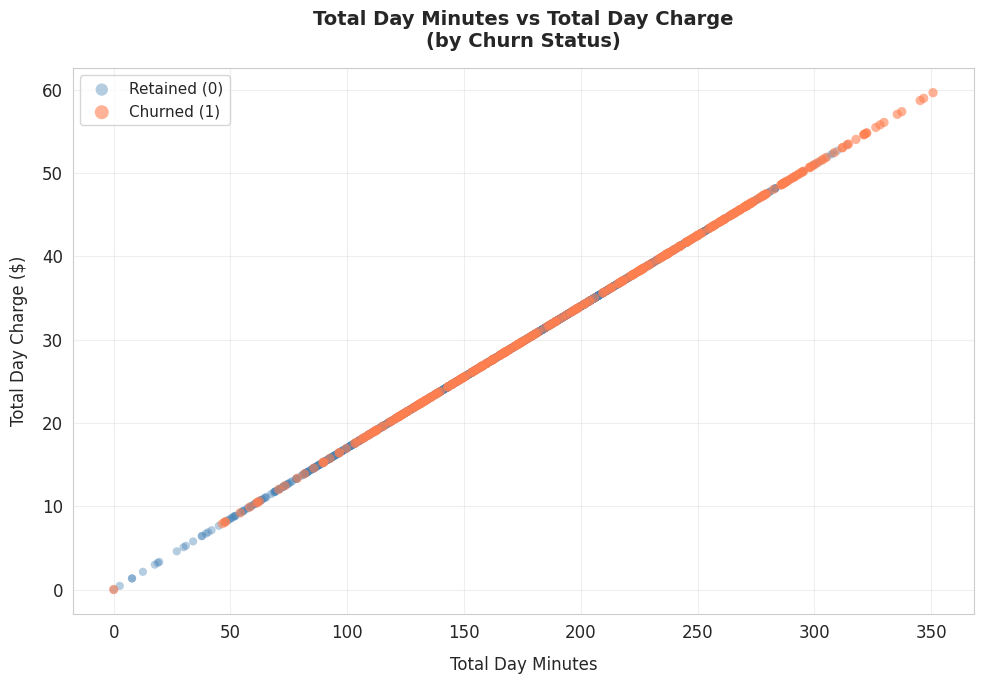

Saved: scatter_day_minutes_charge.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

# Separate churned and retained
retained = df[df['Churn'] == 0]
churned = df[df['Churn'] == 1]

ax.scatter(retained['Total day minutes'],
           retained['Total day charge'],
           alpha=0.4, s=35, color='steelblue',
           edgecolors='none', label='Retained (0)')

ax.scatter(churned['Total day minutes'],
           churned['Total day charge'],
           alpha=0.6, s=45, color='coral',
           edgecolors='none', label='Churned (1)')

ax.set_title('Total Day Minutes vs Total Day Charge\n(by Churn Status)', pad=15)
ax.set_xlabel('Total Day Minutes', labelpad=10)
ax.set_ylabel('Total Day Charge ($)', labelpad=10)
ax.legend(fontsize=11, markerscale=1.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_day_minutes_charge.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: scatter_day_minutes_charge.png")

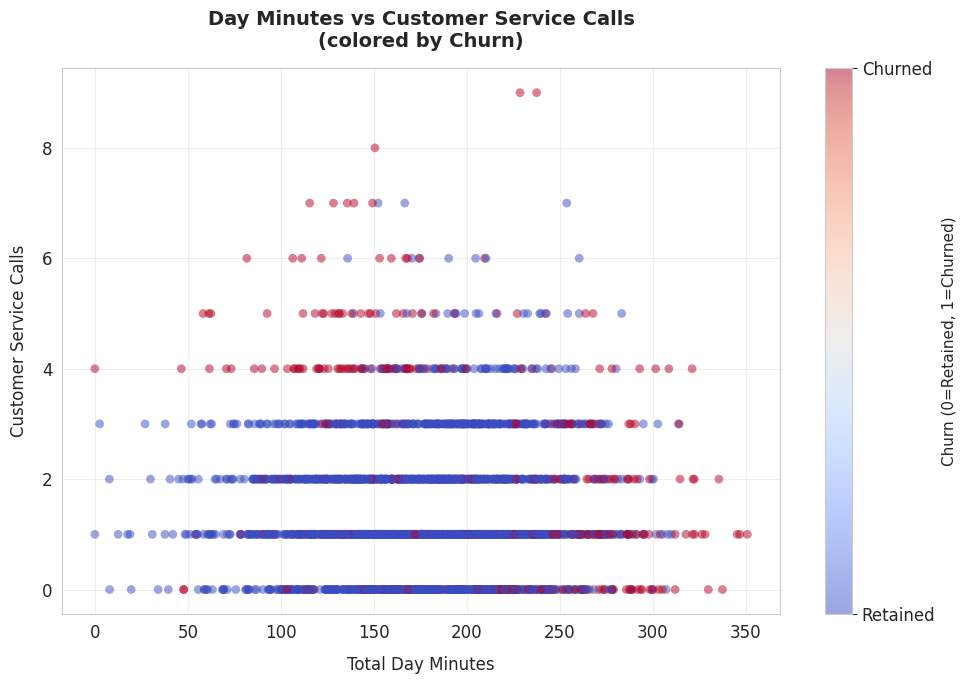

Saved: scatter_minutes_vs_service_calls.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(df['Total day minutes'],
                     df['Customer service calls'],
                     c=df['Churn'],
                     cmap='coolwarm',
                     alpha=0.5,
                     s=40,
                     edgecolors='none')

# Add colorbar as legend
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Churn (0=Retained, 1=Churned)', fontsize=11)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Retained', 'Churned'])

ax.set_title('Day Minutes vs Customer Service Calls\n(colored by Churn)', pad=15)
ax.set_xlabel('Total Day Minutes', labelpad=10)
ax.set_ylabel('Customer Service Calls', labelpad=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_minutes_vs_service_calls.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: scatter_minutes_vs_service_calls.png")

In [ ]:
import os

saved_files = [
    'bar_plot_churn_count.png',
    'bar_plot_intl_plan_churn.png',
    'bar_plot_service_calls_churn.png',
    'line_chart_charges.png',
    'line_chart_churn_by_length.png',
    'scatter_day_minutes_charge.png',
    'scatter_minutes_vs_service_calls.png'
]

print("=" * 55)
print("       EXPORTED FILES — TASK 3 SUMMARY")
print("=" * 55)

for f in saved_files:
    status = "✅ Found" if os.path.exists(f) else "❌ Missing"
    print(f"{status}  →  {f}")

print("✅ Task 3 — Basic Data Visualization completed!")

       EXPORTED FILES — TASK 3 SUMMARY
✅ Found  →  bar_plot_churn_count.png
✅ Found  →  bar_plot_intl_plan_churn.png
✅ Found  →  bar_plot_service_calls_churn.png
✅ Found  →  line_chart_charges.png
✅ Found  →  line_chart_churn_by_length.png
✅ Found  →  scatter_day_minutes_charge.png
✅ Found  →  scatter_minutes_vs_service_calls.png
✅ Task 3 — Basic Data Visualization completed!
